In [1]:
import xarray as xr
import os
import dask
import h5netcdf
import scipy
import numpy as np
import pandas as pd
from datetime import timedelta
import datetime
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker  
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 22,
         'axes.titlesize':'large',
         'xtick.labelsize':18,
         'ytick.labelsize':18,
         'figure.figsize':[10,7],
         'figure.titlesize':22}
pylab.rcParams.update(params)

import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun
from my_classes import DatasetProcessor

In [2]:
dir_in_IFS      = "/perm/paaa/IFS/cabauw"
dir_in_IFS_loobos      = "/perm/paaa/IFS/loobos"
dir_obs         = "/perm/paaa/observations"
dir_dales       = "/perm/paaa/Les/Cases/Catrine/Arseni"

# str_time = '2022-05-17T02'
# end_time = '2022-05-19T00'
str_time = '2022-05-15'
end_time = '2022-05-21'

col = ['#D04848','#6895D2','#F3B95F','#59981A']
sty = ['--','-',':']


exp_names = [
    ('ctrl'     , 'Cabauw_SPPoff_TKEoff' ,  'Control'),
    ('TKE'      , 'Cabauw_SPPoff_TKEon'  ,  'TKE'),
    ('dryMF'    , 'Cabauw_SPPoff_dryMFv1',  'dry MF'),
    ('ctrl_9km' , 'iq88_ctrl_9km'        ,  '9 km')
]

exp_names_new = [
    ('ctrl_lob'     , 'imo0_ctrl_loobos'     ,  'Control l'),
    ('ctrl_9km_lob' , 'iq88_ctrl_9km_loobos' ,  '9 km l')
]

nemo_exp_names = [
    ('SPP_ctrl',  'iq87_SPP_ctrl'  , 'SPP'       , 'grey'),
    ('SPP_conv',  'iqgl_SPP_conv'  , 'SPP conv.' , 'red' ),
    # ('SPP_diff',  'iqhl_SPP_diff'  , 'SPP diff.' , 'blue'),
    ('SPP_noIC',  'iqpa_SPP_noIC_loobos'  , 'SPP noIC'  , 'grey'),
    ('SPP_noIC_conv',  'iqs0_SPP_noIC_conv_loobos'  , 'SPP conv noIC'  , 'red')
]

lead_time = 0 # do you want to analayse FC day1 (leasd_time = 0) or FC day2 (leasd_time = 24) ? 

#######################################
# Time limits
t0 = datetime.datetime.strptime(str_time, "%Y-%m-%d")
t1 = datetime.datetime.strptime(end_time, "%Y-%m-%d")


# Cabauw (51.971°N, 4.927°E)
Cabauw_lat, Cabauw_lon = 51.971, 4.927  
Cabauw_levels = [5,60,100,180]
# Loobos (52.16648°N, 5.74355°E)
Loobos_lat, Loobos_lon = 52.166, 5.744  
Loobos_levels = [24,]



### Open OBS

In [3]:
#### CABAUW ####
################
cabauw = {}
# Surface
obs_name = "cesar_surface_flux"
datestamp = "2022"

files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_surf_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
obs_surf_flx['time'] = obs_surf_flx['time'].astype('datetime64[ns]') + np.timedelta64(2,'h')
obs_surf_flx = obs_surf_flx.resample(time='1h',label='right').mean()  ## Label right or left??????

# Tower
obs_name = "cesar_tower_flux"
datestamp = "2022"

files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_tower_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
# obs_tower_flx['time'] = obs_tower_flx['time'].astype('datetime64[ns]') + np.timedelta64(2,'h')
# obs_tower_flx = obs_tower_flx.resample(time='1h',label='right').mean()  ## Label right or left??????

In [4]:
### import CO2 concentration ## 
file = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if 'CO2' in f and f.endswith('.csv')][0]
print ('Dataset name: '+file[30:-4])
# Read the first two rows separately
headers =  pd.read_csv(file, nrows=1).columns.tolist()

# Read the actual data, skipping the units row
df = pd.read_csv(file)
df.columns.values[0] = "time"
df = df.set_index("time")

# # Convert to xarray
ds = df.to_xarray()
for var in ds.variables:
    if var =='time':
        continue
    elif 'flag' in var:
        ds[var].attrs["units"] = ''
    else: 
        ds[var].attrs["units"] = 'PPM'

# # Optional: parse the time if it's not already datetime
ds["time"] = pd.to_datetime(df.index) + np.timedelta64(2,'h') # to LT (CEST)

# # Now you can assign it to your dict:
cabauw[file[30:-4]] = ds


Dataset name: Cabauw_CO2_May2022


In [5]:
#### LOOBOS ####
################
obs_name = "Loobos_"

files = [os.path.join(dir_obs+'/Loobos', f) for f in os.listdir(dir_obs+'/Loobos') if f.startswith(obs_name) and f.endswith('.csv')]

loobos = {}
for file in files:
    print ('Dataset name: '+file[38:-4])
    # loobos[file[38:-4]] = pd.read_csv(file,skiprows=[1])
    # loobos[file[38:-4]] = loobos[file[38:-4]].to_xarray()


    # Read the first two rows separately
    headers = pd.read_csv(file, nrows=1).columns.tolist()
    units = pd.read_csv(file, nrows=1).iloc[0].tolist()

    # Read the actual data, skipping the units row
    df = pd.read_csv(file, skiprows=[1])

    # Set correct headers
    df.columns = headers

    # Convert to xarray
    ds = df.to_xarray()

    # Assign units as attributes to the DataArray variables
    for var_name, unit in zip(headers[1:], units[1:]):  # skip Timestamp
        if var_name in ds:
            ds[var_name].attrs["units"] = unit

    # Optional: parse the time if it's not already datetime
 
    ds["time"] = pd.to_datetime(df[df.columns[0]])
    
    ds['index'] = ds['time']
    
    ds = ds.drop_vars('time')
    ds = ds.drop_vars('dim_0')
    ds = ds.rename({'index': 'time'})
    ds = ds.set_coords("time")
    # ds = ds.rename({'dim_0': 'index'})
    ds = ds.swap_dims({'dim_0': 'time'})
    # Now you can assign it to your dict:
    loobos[file[38:-4]] = ds

Dataset name: Meteorology
Dataset name: Tower_co2_flux
Dataset name: airsamples_O2_CO2
Dataset name: Aircraft_morn_flux
Dataset name: Air_Quality
Dataset name: Fluxes
Dataset name: airsamples_vertical_all
Dataset name: Aircraft_co2_mol
Dataset name: Aircraft_aft_flux


In [6]:
### import BLH ## 
file = [os.path.join(dir_obs+'/Loobos', f) for f in os.listdir(dir_obs+'/Loobos') if 'BLH' in f and f.endswith('.csv')][0]
print ('Dataset name: '+file[31:-4])
# Read the first two rows separately
headers = ['time','BLH_radio','BLH_plane']
units   = ['','m','m']

# Read the actual data, skipping the units row
df = pd.read_csv(file)

# # Set correct headers
df.columns = headers
df = df.set_index("time")

# # Convert to xarray
ds = df.to_xarray()

# Assign units as attributes to the DataArray variables
for var_name, unit in zip(headers[1:], units[1:]):  # skip Timestamp
    if var_name in ds:
        ds[var_name].attrs["units"] = unit

# # Optional: parse the time if it's not already datetime
ds["time"] = pd.to_datetime(df.index) + np.timedelta64(1, 'h') # convert to LT (CEST)

# # Now you can assign it to your dict:
loobos[file[31:-4]] = ds


Dataset name: BLH


### Open IFS

In [7]:
srf_nemo_slab_dict = {}
srf_nemo_dict = {}

for exp, exp_longname, _,_ in nemo_exp_names:
    if'SPP_noIC' in exp:
        l_time = f't{lead_time}'
    else:
        l_time = ''
    processor_ensemble = DatasetProcessor(exp_longname, dir_in_IFS_loobos + '/eps_nemo',l_time)
    srf_nemo_slab_dict[exp] = processor_ensemble.get_ds_srf_slab()
    srf_nemo_dict[exp]      = processor_ensemble.get_ds_srf()

srf_fc_slab_dict = {}
srf_fc_dict      = {}
z_fc_slab_dict   = {}
z_fc_dict        = {}

for exp, exp_longanme, label in exp_names:
    processor_fc = DatasetProcessor(exp_longanme, dir_in_IFS)
    srf_fc_slab_dict[exp] = processor_fc.get_ds_srf_slab()
    srf_fc_dict[exp]      = processor_fc.get_ds_srf()
    z_fc_slab_dict[exp]   = processor_fc.get_ds_z_slab()
    z_fc_dict[exp]        = processor_fc.get_ds_z()


for exp, exp_longanme, label in exp_names_new:
    l_time = f't{lead_time}'
    processor_fc = DatasetProcessor(exp_longanme, dir_in_IFS_loobos,l_time)
    z_fc_slab_dict[exp]   = processor_fc.get_ds_z_slab()
    z_fc_dict[exp]        = processor_fc.get_ds_z()

Processing iq87_SPP_ctrl
Cannot find .nc file for iq87_SPP_ctrl_srf .
Cannot find .nc file for iq87_SPP_ctrl_z .
Done_____________
Processing iqgl_SPP_conv
Cannot find .nc file for iqgl_SPP_conv_srf .
Cannot find .nc file for iqgl_SPP_conv_z .
Done_____________
Processing iqpa_SPP_noIC_loobos
Cannot find .nc file for iqpa_SPP_noIC_loobos_z .
Done_____________
Processing iqs0_SPP_noIC_conv_loobos
Cannot find .nc file for iqs0_SPP_noIC_conv_loobos_z .
Done_____________
Processing Cabauw_SPPoff_TKEoff
trying to convert kg m**-2 to PPM for variable aco2nee
trying to convert kg m**-2 to PPM for variable aco2gpp
trying to convert kg m**-2 to PPM for variable aco2rec
converting kg m**-2 s**-1 to PPM for variable fco2nee, careful!
converting kg m**-2 s**-1 to PPM for variable fco2gpp, careful!
converting kg m**-2 s**-1 to PPM for variable fco2rec, careful!
Units unknown for variable u_flx_conv
Units unknown for variable v_flx_conv
Filling up units for co2_flx_conv
Units unknown for variable u_

### Open DALES

In [8]:
#####################
### DALES profiles ###
files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'profiles' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_prof    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':1000})#.sel(time=slice(str_time,end_time))
dales_prof['time'] = dales_prof['time'].astype('datetime64[ns]') - np.timedelta64(1,'D')
dales_prof = dales_prof.sel(time=slice(str_time,end_time))
## Interpolate half levels to full levels
for var in dales_prof.data_vars:
    if 'zm' in dales_prof[var].coords:
        # Interpolate the variable along the 'zm' coordinate
        dales_prof[var] = dales_prof[var].interp(zm=dales_prof.zt)
    
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_prof[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_prof[var]/1000000) # ????????
        dales_prof[var+'_ppm'].attrs['units'] = 'PPM'
        dales_prof[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'

# Drop the unnecessary dimensions and coordinates
dales_prof = dales_prof.drop_dims(["zm"])
dales_prof = dales_prof.sel(zt=slice(0,7000))
dales_prof_hr = dales_prof.resample(time='1h',label='left').mean().chunk({'time':-1,'zt':-1})

Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/profiles.001.nc']


In [9]:
#####################
### DALES 3d fields ###

## domain limit:
lat_min = 52
lat_max = 52.4
lon_min = 5.5
lon_max = 5.8

files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'loobos_' in f and '_3d' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_3d    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':24,'zt':4,'xt':-1,'yt':-1})
# convert UTC to local time (+2 hours)
dales_3d['time'] = dales_3d['time'].astype('datetime64[ns]') + np.timedelta64(2,'D') + np.timedelta64(2,'h')
dales_3d = dales_3d.sel(time=slice(str_time,end_time))
# Select domain around the tower
dales_3d = dales_3d.where((dales_3d['lat']>lat_min).compute() & (dales_3d['lat']<lat_max).compute() &
                          (dales_3d['lon']>lon_min).compute() & (dales_3d['lon']<lon_max).compute(),drop=True)

for var in dales_3d.data_vars:
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_3d[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_3d[var]/1000000) # ???????
        dales_3d[var+'_ppm'].attrs['units'] = 'PPM'
        dales_3d[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'
dales_2d    = dales_3d.mean(('xt','yt'))
# dales_2d = dales_2d.chunk({'time':-1,'zt':-1})


dales_3d_cabauw = dales_3d.where((dales_3d['lat']>lat_min).compute() & (dales_3d['lat']<lat_max).compute() &
                          (dales_3d['lon']>lon_min).compute() & (dales_3d['lon']<lon_max).compute(),drop=True)
dales_3d_loobos = 

Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv004_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_buoy_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_thl_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_w_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_v_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv001_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_u_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv002_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_ql_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv003_3d.nc']


### Compute Diurnal Amplitude Range DCR

In [32]:
dhr_dict = {}

for lev in [27, 67, 127, 207]:
    co2 = cabauw['Cabauw_CO2_May2022'][f'co2_{lev}m']
    flag = cabauw['Cabauw_CO2_May2022'][f'co2_flag_{lev}m']
    
    co2_clean = co2.where(flag == 'O')

    # Create a DataArray of day timestamps
    days = co2_clean.time.dt.floor('D')
    co2_by_day = co2_clean.groupby(days)

    dhr_vals = []
    hour_max_vals = []
    hour_min_vals = []
    date_vals = []

    for day, group in co2_by_day:
        if group.notnull().any():
            max_idx = group.argmax('time')
            min_idx = group.argmin('time')

            time_max = group.time[max_idx].item()
            time_min = group.time[min_idx].item()

            co2_max = group[max_idx].item()
            co2_min = group[min_idx].item()

            dhr_vals.append(co2_max - co2_min)
            hour_max_vals.append(pd.to_datetime(time_max).hour)
            hour_min_vals.append(pd.to_datetime(time_min).hour)
            date_vals.append(pd.to_datetime(day.item()))
    
    dhr_dict[f'DHR_{lev}m'] = xr.DataArray(dhr_vals, coords={'date': date_vals}, dims='date')
    dhr_dict[f'hr_max_{lev}m'] = xr.DataArray(hour_max_vals, coords={'date': date_vals}, dims='date')
    dhr_dict[f'hr_min_{lev}m'] = xr.DataArray(hour_min_vals, coords={'date': date_vals}, dims='date')

# Combine into a Dataset
DHR = xr.Dataset(dhr_dict)

### Interpolate to tower locations (Cabauw and Loobos)

In [24]:
exp_names_new

[('ctrl_lob', 'imo0_ctrl_loobos', 'Control l'),
 ('ctrl_9km_lob', 'iq88_ctrl_9km_loobos', '9 km l')]

In [ ]:
### Interpolate spatially using Inverse Distance Weighting 
def inverse_distance_weighting(ds,target_lat,target_lon):
    # Get latitude and longitude arrays (assumed to be 1D or 2D broadcastable)
    lat = ds['latitude']
    lon = ds['longitude']
    # Compute distance in degrees
    dist = np.sqrt((lat - target_lat)**2 + (lon - target_lon)**2)
    # Avoid division by zero (e.g. exact match)
    dist = dist.where(dist != 0, other=1e-10)
    # Inverse distance weights
    weights = 1 / dist
    weights = weights / weights.sum(dim=('latitude', 'longitude'))
    # Now apply the weights to average over lat/lon
    # Broadcast weights to match dimensions
    weighted = ds.weighted(weights)
    data_idw = weighted.mean(dim=('latitude', 'longitude'))
    return data_idw

IFS_Cabauw_prof = {}
IFS_Cabauw_srf = {}
IFS_Loobos_prof = {}
IFS_Loobos_srf = {}
all_heights = np.unique(np.concatenate([z_fc_dict[exp]['height'].values, Cabauw_levels,Loobos_levels]))
for exp,_,_ in exp_names:
    IFS_Cabauw_prof[exp] = inverse_distance_weighting(z_fc_dict[exp],Cabauw_lat,Cabauw_lon)
    IFS_Cabauw_srf[exp]  = inverse_distance_weighting(srf_fc_dict[exp],Cabauw_lat,Cabauw_lon)
    #
    IFS_Loobos_prof[exp] = inverse_distance_weighting(z_fc_dict[exp],Loobos_lat,Loobos_lon)
    IFS_Loobos_srf[exp]  = inverse_distance_weighting(srf_fc_dict[exp],Loobos_lat,Loobos_lon)

    ### interpolate to tower's heights 
    IFS_Cabauw_prof[exp] = IFS_Cabauw_prof[exp].interp(height=all_heights)
    IFS_Loobos_prof[exp] = IFS_Loobos_prof[exp].interp(height=all_heights)

for exp,_,_ in exp_names_new:
    IFS_Cabauw_prof[exp] = inverse_distance_weighting(z_fc_dict[exp],Cabauw_lat,Cabauw_lon)
    # IFS_Cabauw_srf[exp]  = inverse_distance_weighting(srf_fc_dict[exp],Cabauw_lat,Cabauw_lon)
    #
    IFS_Loobos_prof[exp] = inverse_distance_weighting(z_fc_dict[exp],Loobos_lat,Loobos_lon)
    # IFS_Loobos_srf[exp]  = inverse_distance_weighting(srf_fc_dict[exp],Loobos_lat,Loobos_lon)

    ### interpolate to tower's heights 
    IFS_Cabauw_prof[exp] = IFS_Cabauw_prof[exp].interp(height=all_heights)
    IFS_Loobos_prof[exp] = IFS_Loobos_prof[exp].interp(height=all_heights)

for exp,_,_,_ in nemo_exp_names:
    IFS_Cabauw_srf[exp]  = inverse_distance_weighting(srf_nemo_dict[exp],Cabauw_lat,Cabauw_lon)
    IFS_Loobos_srf[exp]  = inverse_distance_weighting(srf_nemo_dict[exp],Loobos_lat,Loobos_lon)

# Plotting

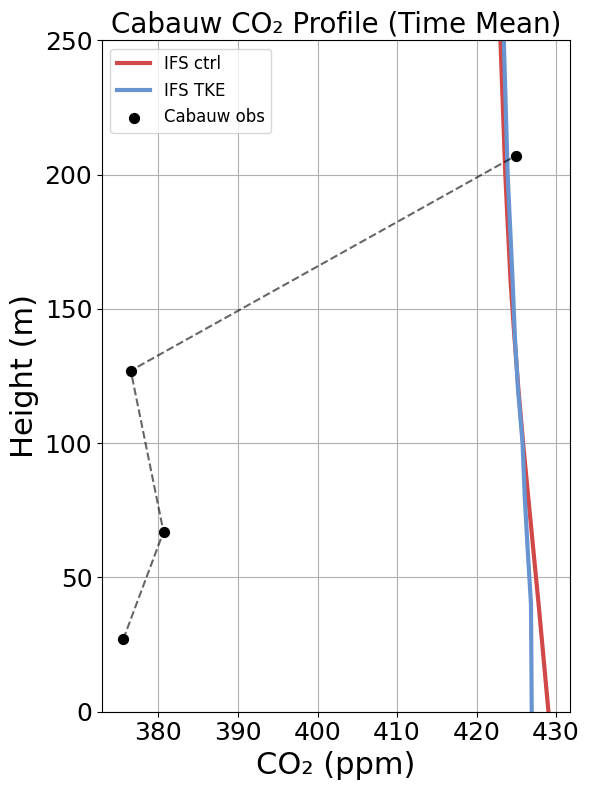

In [12]:
### Vertical profile of CO2 at Cabauw ###
################################################################
# --------------------------------------------
# Settings
# --------------------------------------------
exps = ['ctrl', 'TKE']
cabauw_heights = np.array([27, 67, 127, 207])
site_key = 'cabauw'
obs_ds = cabauw['Cabauw_CO2_May2022']

# Time array for interpolation (use Cabauw observation time)
cabauw_time = obs_ds['time']

# --------------------------------------------
# Prepare figure
# --------------------------------------------
fig, ax = plt.subplots(figsize=(6, 8))

# --------------------------------------------
# Plot experiments as lines
# --------------------------------------------
for ie, exp in enumerate(exps):
    # Interpolate to Cabauw observation times if needed
    ifs_values_interp = IFS_Cabauw_prof[exp]['co2'].interp(time=cabauw_time)
    # Mean over time
    mean_ifs = ifs_values_interp.mean(dim='time').sel(height=slice(0, 250))

    # Plot line connecting heights
    ax.plot(mean_ifs,mean_ifs.height,label=f'IFS {exp}',c=col[ie],lw=3)

# --------------------------------------------
# Plot observations as dots
# --------------------------------------------
obs_means = []

for sel_z in cabauw_heights:
    obs_var = f'co2_{sel_z}m'
    mean_obs = obs_ds[obs_var].mean(dim='time').values
    obs_means.append(mean_obs)

obs_means = np.array(obs_means)

# Plot dots
ax.scatter(obs_means, cabauw_heights, color='k', label='Cabauw obs', zorder=5, s=50)

# Optional: connect observation dots with a thin line
ax.plot(obs_means, cabauw_heights, color='k', linestyle='--', alpha=0.6)

# --------------------------------------------
# Formatting
# --------------------------------------------
ax.set_xlabel('CO₂ (ppm)')
ax.set_ylabel('Height (m)')
ax.set_ylim(0, 250)
ax.set_title('Cabauw CO₂ Profile (Time Mean)',fontsize=20)
ax.grid(True)
ax.legend()
plt.tight_layout()

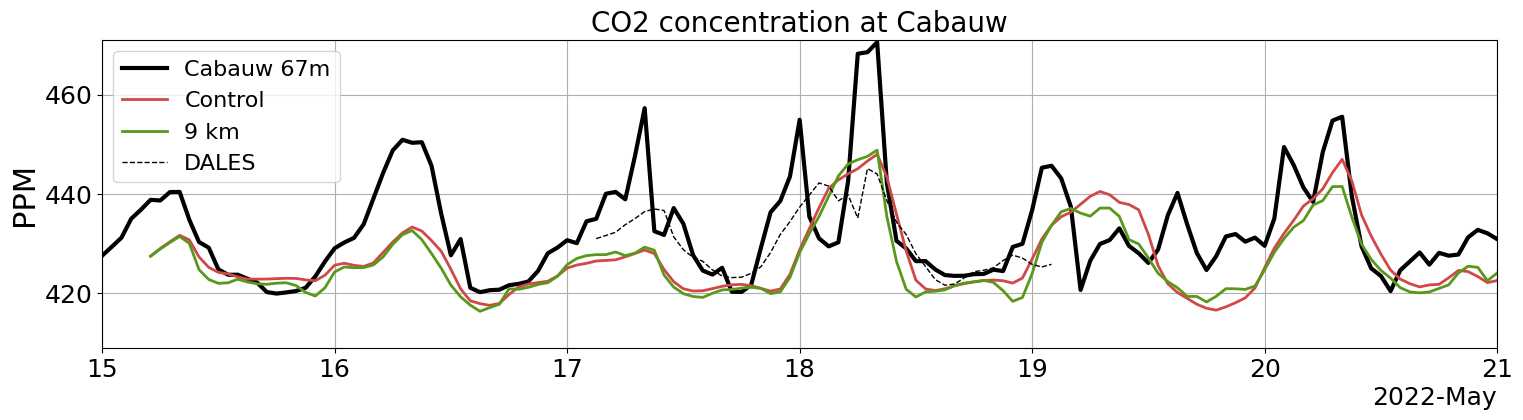

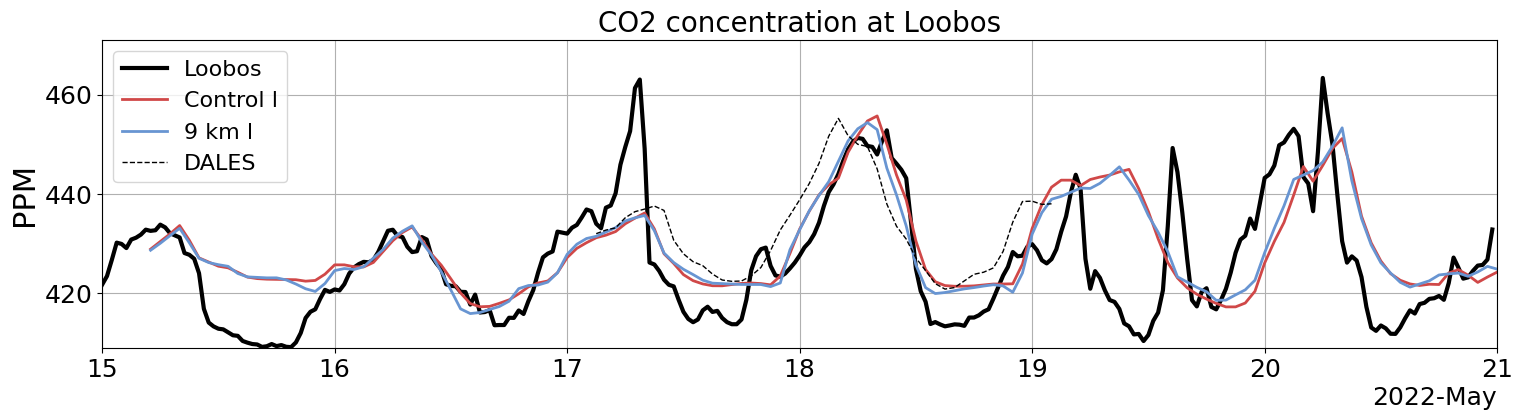

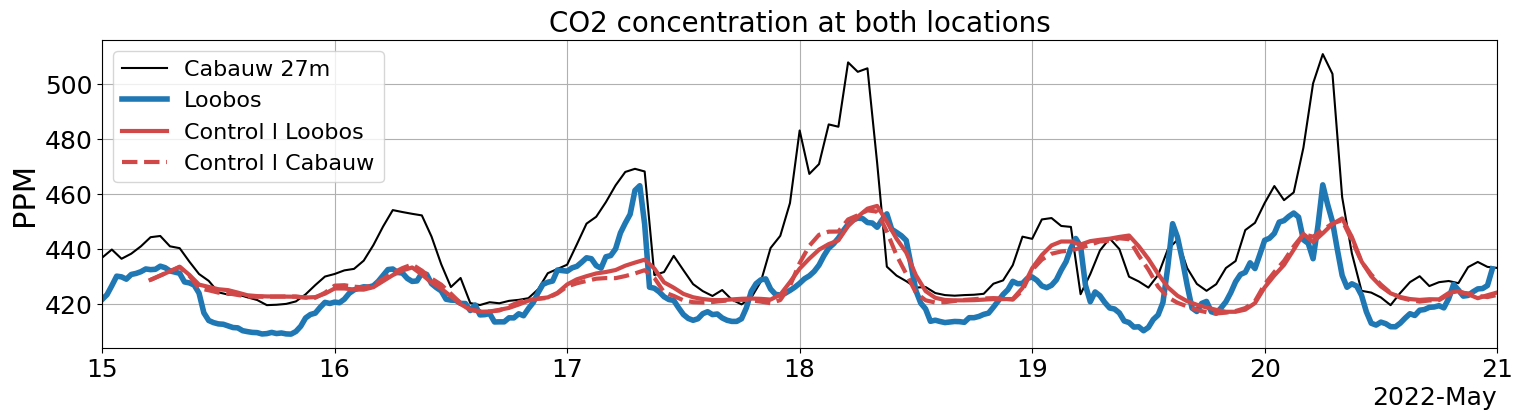

In [33]:
#########################################
#### Concentration and DHR at Cabauw ####
height = 67 #m
plt.figure(figsize=(18,4))
cabauw['Cabauw_CO2_May2022'][f'co2_{height}m'].where(cabauw['Cabauw_CO2_May2022'][f'co2_flag_{height}m']=='O').plot(label=f'Cabauw {height}m',lw=3,c='k')
for (exp, _, label), c in zip(exp_names, col):
    if 'ctrl' in exp:
        IFS_Cabauw_prof[exp]['co2'].sel(height=height,method='nearest').plot(label=label,c=c,lw=2)
dales_2d['sv004_ppm'].sel(zt=height,method='nearest').plot(label='DALES', lw=1,c='k',ls='--')

## SPP profiles of CO2 not available! 
# for (exp, _, label,c) in nemo_exp_names:
#     if exp in ['SPP_noIC',]:
#         blh_min = IFS_Cabauw_prof[exp]['co2'].min(dim='number')
#         blh_max = IFS_Cabauw_prof[exp]['co2'].max(dim='number')

#         plt.fill_between(
#             IFS_Cabauw_prof[exp]['time'].values,
#             blh_min.values,
#             blh_max.values,
#             color=c,
#             alpha=0.3,
#             label=label
#         )

plt.legend(fontsize=16)
# plt.xlim([dales_2d['time'][0],dales_2d['time'][-1]])
plt.xlabel('')
plt.ylabel('PPM')
plt.title('CO2 concentration at Cabauw', fontsize=20)
plt.xlim([t0,t1])
plt.ylim([409,471])
plt.grid(True)

#########################################
#### Concentration and DHR at Loobos ####
height = 24 #m
plt.figure(figsize=(18,4))
loobos['Air_Quality']['co2_mixing_ratio'].plot(label='Loobos',lw=3,c='k')
# for (exp, _, label), c in zip(exp_names, col):
#     if 'ctrl' in exp:
#         IFS_Loobos_prof[exp]['co2'].sel(height=height,method='nearest').plot(label=label,c=c,lw=2)
for (exp, _, label), c in zip(exp_names_new, col):
    if 'ctrl' in exp:
        IFS_Loobos_prof[exp]['co2'].sel(height=height,method='nearest').plot(label=label,c=c,lw=2,ls='-')
dales_2d['sv004_ppm'].sel(zt=height,method='nearest').plot(label='DALES', lw=1,c='k',ls='--')

## SPP profiles of CO2 not available! 
# for (exp, _, label,c) in nemo_exp_names:
#     if exp in ['SPP_noIC',]:
#         blh_min = IFS_Loobos_prof[exp]['co2'].min(dim='number')
#         blh_max = IFS_Loobos_prof[exp]['co2'].max(dim='number')

#         plt.fill_between(
#             IFS_Loobos_prof[exp]['time'].values,
#             blh_min.values,
#             blh_max.values,
#             color=c,
#             alpha=0.3,
#             label=label
#         )

plt.legend(fontsize=16)
# plt.xlim([dales_2d['time'][0],dales_2d['time'][-1]])
plt.xlabel('')
plt.ylabel('PPM')
plt.title('CO2 concentration at Loobos', fontsize=20)
plt.xlim([t0,t1])
plt.ylim([409,471])
plt.grid(True)

# ####################################
#### Compare Loobos and Cabauw ####
level = 27
exp = 'ctrl'
plt.figure(figsize=(18,4))
cabauw['Cabauw_CO2_May2022'][f'co2_{level}m'].where(cabauw['Cabauw_CO2_May2022'][f'co2_flag_{level}m']=='O').plot(label=f'Cabauw {level}m',lw=1.5,c='k')
loobos['Air_Quality']['co2_mixing_ratio'].plot(label='Loobos',lw=4)
for (exp, _, label), c in zip(exp_names_new, col):
    if exp in ['ctrl_lob',]:
        IFS_Loobos_prof[exp]['co2'].sel(height=level,method='nearest').plot(label=label+' Loobos',c=c,lw=3)
        IFS_Cabauw_prof[exp]['co2'].sel(height=level,method='nearest').plot(label=label+' Cabauw',c=c,lw=3,ls='--')
plt.legend(fontsize=16)
# plt.xlim([dales_2d['time'][0],dales_2d['time'][-1]])
plt.xlabel('')
plt.ylabel('PPM')
plt.title('CO2 concentration at both locations', fontsize=20)
plt.xlim([t0,t1])
plt.grid(True)

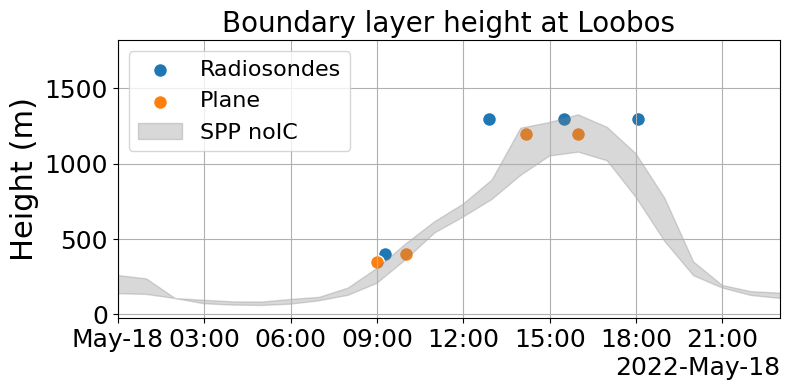

In [41]:
plt.figure(figsize=(8,4))
loobos['BLH']['BLH_radio'].plot.scatter(label='Radiosondes',s=100)
loobos['BLH']['BLH_plane'].plot.scatter(label='Plane',s=100)
for (exp, _, label), c in zip(exp_names, col):
    if exp in ['ctrl','ctrl_9km']:
        IFS_Loobos_srf[exp]['blh'].plot(label=label,c=c,lw=3,ls='-')


for (exp, _, label,c) in nemo_exp_names:
    if exp in ['SPP_noIC',]:
        blh_min = IFS_Loobos_srf[exp]['blh'].min(dim='number')
        blh_max = IFS_Loobos_srf[exp]['blh'].max(dim='number')

        plt.fill_between(
            IFS_Loobos_srf[exp]['time'].values,
            blh_min.values,
            blh_max.values,
            color=c,
            alpha=0.3,
            label=label
        )

plt.legend(fontsize=16)
# plt.xlim([dales_2d['time'][26],dales_2d['time'][-1]])
plt.xlim([pd.Timestamp('2022-05-18 00:00'), pd.Timestamp('2022-05-18 23:00')])

plt.ylabel('Height (m)')
plt.xlabel('')
plt.title('Boundary layer height at Loobos', fontsize=20)
plt.grid(True)
plt.tight_layout()

In [42]:
def interp_pblh(Ri, zt, threshold=0.25):
    # Difference from threshold
    diff = Ri - threshold

    # Condition: Ri > 0.25
    mask = diff > 0

    # Find index along zt where Ri first exceeds threshold
    ri_ind = mask.argmax(dim="zt")

    # Gather values just before and after the threshold crossing
    ri_low = Ri.isel(zt=ri_ind - 1)
    ri_high = Ri.isel(zt=ri_ind)

    zt_low = zt.isel(zt=ri_ind - 1)
    zt_high = zt.isel(zt=ri_ind)

    # Linear interpolation to where Ri == threshold
    pblh = zt_low + (zt_high - zt_low) * ((threshold - ri_low) / (ri_high - ri_low))

    return pblh

In [62]:
#### Not accurate! you need the surface values! this lowest level is about 12 m ####
thv_surf = dales_prof_hr['thv'].sel(zt=0,method='nearest') +2.5 ####?????????????
z_surf  = dales_prof_hr['zt'].sel(zt=0,method='nearest') -10
u_surf  = dales_prof_hr['u'].sel(zt=0,method='nearest') *0.2
v_surf  = dales_prof_hr['v'].sel(zt=0,method='nearest') *0.2
####################

num = mfun.g/(thv_surf) * (dales_prof_hr['thv'] - (thv_surf)) * (dales_prof_hr['zt']-(z_surf))
den = (dales_prof_hr['u'] - (u_surf))**2 + (dales_prof_hr['v'] - (v_surf))**2

# num = mfun.g/dales_prof_hr['thv'] * (dales_prof_hr['thv'].diff('zt')) * (dales_prof_hr['zt'].diff('zt'))
# den = (dales_prof_hr['u'].diff('zt'))**2 + (dales_prof_hr['v'].diff('zt'))**2

Ri  = num/den 

pblh = interp_pblh(Ri.compute(),dales_prof_hr['zt'],0.25)

pblh['time'] = pblh['time'].astype('datetime64[ns]') + np.timedelta64(3,'h')

(np.float64(19128.0), np.float64(19132.0))

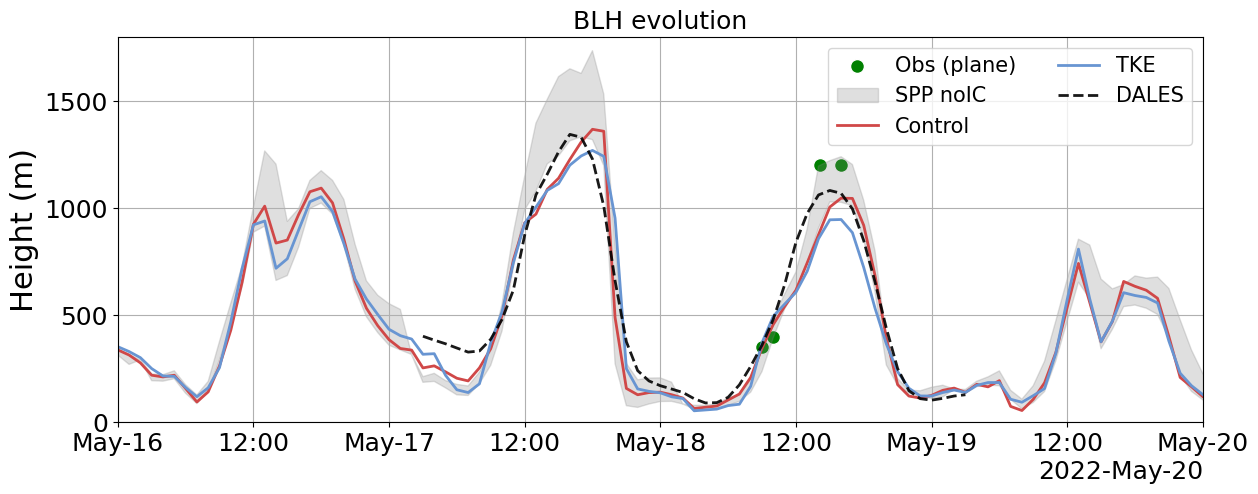

In [74]:
### evolution of the BLH
t0 = datetime.datetime.strptime('2022-05-16', "%Y-%m-%d")
t1 = datetime.datetime.strptime('2022-05-20', "%Y-%m-%d")
# Set up the figure
fig, ax = plt.subplots(figsize=(14, 5))
#plot obs
loobos['BLH']['BLH_plane'].plot.scatter(label='Obs (plane)',s=100,c='g')

# Plot shaded regions for ensemble runs
for i, (ens_key,_,ens_lab, ens_color) in enumerate(nemo_exp_names[2:3]):
    # # Plot all lines in grey
    # for number in srf_nemo_slab_dict[ens_key]['number']:
    #     srf_nemo_slab_dict[ens_key]['blh'].sel(number=number).plot(x='time', color=ens_color, alpha=0.5, linewidth=0.8, ax=ax)
    blh_min = srf_nemo_slab_dict[ens_key]['blh'].min(dim='number')
    blh_max = srf_nemo_slab_dict[ens_key]['blh'].max(dim='number')
    
    ax.fill_between(
        srf_nemo_slab_dict[ens_key]['time'].values,
        blh_min.values,
        blh_max.values,
        color=ens_color,
        alpha=max(0.12, 0.25 - 0.6 * i),
        label=ens_lab
    )

for (exp,_, label), c in zip(exp_names[0:2], col):
    srf_slab = srf_fc_slab_dict[exp]
    # Plot mean line
    srf_slab['blh'].plot(label=label, color=c, lw=2,alpha=1)

pblh.plot(x='time',label='DALES',lw=2,ls='--',c='k',alpha=0.9)

ax.set_title('BLH evolution',fontsize=18)
ax.set_ylabel('Height (m)')
ax.set_xlabel('')
ax.set_ylim([0,1800])
ax.legend(fontsize=15,ncol=2)
plt.grid(True)
ax.set_xlim(t0, t1)

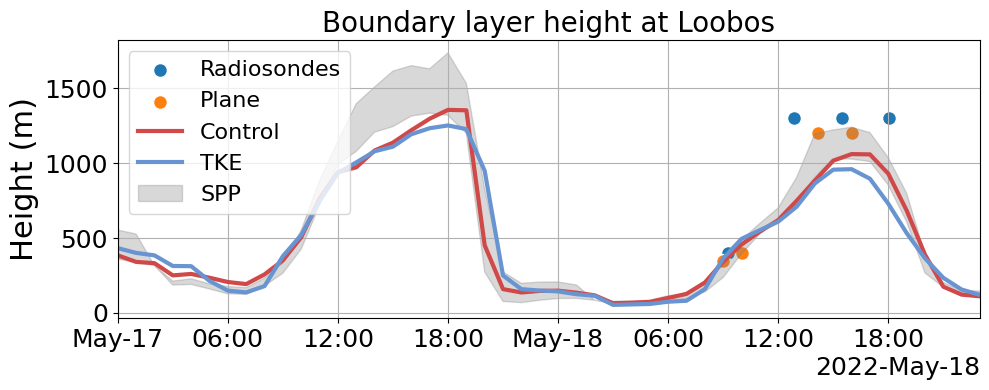

In [70]:
plt.figure(figsize=(10,4))
loobos['BLH']['BLH_radio'].plot.scatter(label='Radiosondes',s=100)
loobos['BLH']['BLH_plane'].plot.scatter(label='Plane',s=100)
# loobos['BLH']['BLH_radio'].plot.scatter(s=60,c='k')
# loobos['BLH']['BLH_plane'].plot.scatter(label='Obs',s=60,c='k')
for (exp, _, label), c in zip(exp_names, col):
    if exp in ['ctrl','TKE']:
        IFS_Loobos_srf[exp]['blh'].plot(label=label,c=c,lw=3,ls='-')

blh_min = srf_nemo_slab_dict['SPP_noIC']['blh'].min(dim='number')
blh_max = srf_nemo_slab_dict['SPP_noIC']['blh'].max(dim='number')

plt.fill_between(
    srf_nemo_slab_dict['SPP_noIC']['time'].values,
    blh_min.values,
    blh_max.values,
    color='grey',
    alpha=0.3,
    label='SPP'
)


plt.legend(fontsize=16,ncol=1)
# plt.xlim([dales_2d['time'][26],dales_2d['time'][-1]])
plt.xlim([pd.Timestamp('2022-05-17 00:00'), pd.Timestamp('2022-05-18 23:00')])

plt.ylabel('Height (m)')
plt.xlabel('')
plt.title('Boundary layer height at Loobos', fontsize=20)
plt.grid(True)
plt.tight_layout()